In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ab_test_data = pd.read_csv('ab_test_data.csv')

In [7]:
ab_test_data.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [8]:
ab_test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [9]:
ab_test_data.describe()

,conversion
count,19998.000000
mean,0.075008
std,0.263410
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [12]:
users = ab_test_data.groupby('test_group').size()
print(users)

test_group
a    10013
b     9985
dtype: int64


In [14]:
conversions = ab_test_data.groupby('test_group')['conversion'].sum()
print(conversions)

test_group
a    611
b    889
Name: conversion, dtype: int64


In [20]:
cr = conversions/users
cr_percent = cr * 100
print("Відсоток конверсії за групами:")
print(cr_percent.round(1).astype(str) + '%')

Відсоток конверсії за групами:
test_group
a    6.1%
b    8.9%
dtype: object


In [26]:
ab_test_data['timestamp'] = pd.to_datetime(ab_test_data['timestamp'])
start_date = ab_test_data['timestamp'].min()
end_date = ab_test_data['timestamp'].max()
durability = end_date - start_date
durability.days

21

In [27]:
from scipy import stats
alpha = 0.05

statistic, pvalue = stats.ttest_ind(
    ab_test_data[ab_test_data.test_group == 'a']['conversion'],
    ab_test_data[ab_test_data.test_group == 'b']['conversion'],
    alternative='less'
)

if pvalue < alpha:
    print("Відхиляємо нульову гіпотезу: різниця статистично значуща")
else:
    print("Не відхиляємо нульову гіпотезу: різниця не значуща")

Відхиляємо нульову гіпотезу: різниця статистично значуща


In [28]:
pvalue

2.6455288192589385e-14

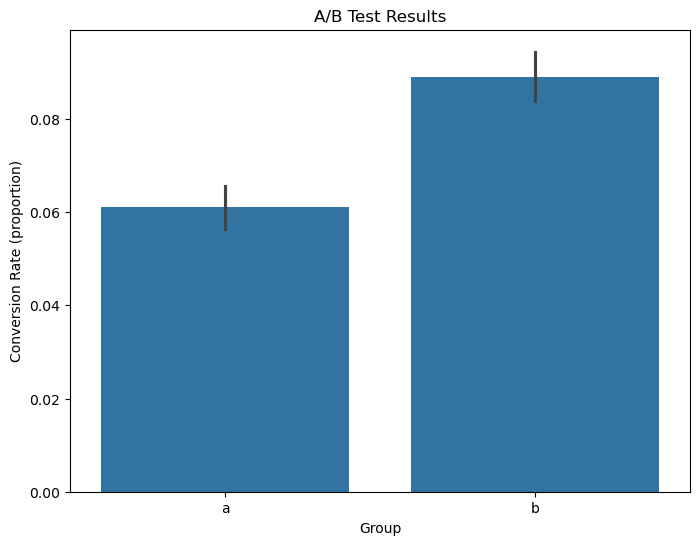

In [35]:
plt.figure(figsize=(8, 6))
sns.barplot(x=ab_test_data['test_group'], 
            y=ab_test_data['conversion'], 
            errorbar=('ci', 95)) 

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Conversion Rate (proportion)')

plt.savefig('convertion_rate.png')

plt.show()

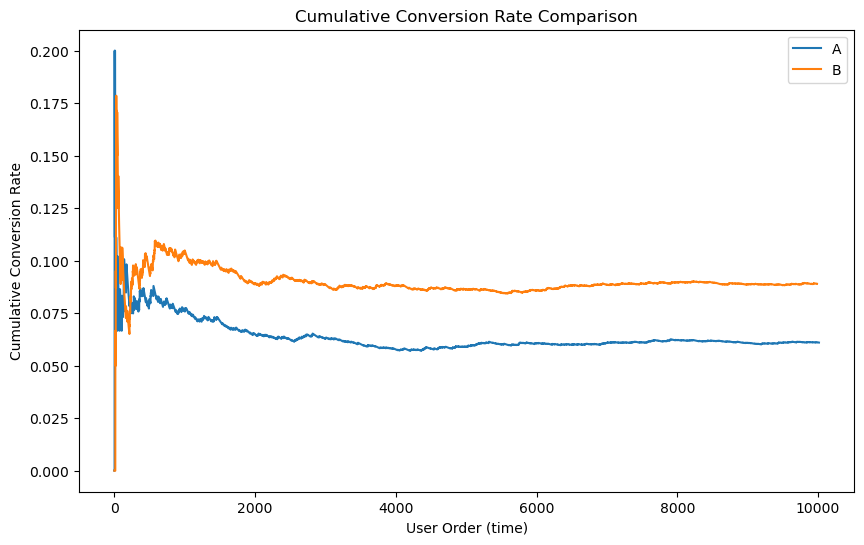

In [38]:
cumulative_metric_a = ab_test_data[ab_test_data['test_group'] == 'a']['conversion'].expanding().mean().reset_index(drop=True)
cumulative_metric_b = ab_test_data[ab_test_data['test_group'] == 'b']['conversion'].expanding().mean().reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_metric_a, label='A')
plt.plot(cumulative_metric_b, label='B')

plt.title('Cumulative Conversion Rate Comparison')
plt.xlabel('User Order (time)')
plt.ylabel('Cumulative Conversion Rate')

plt.legend()
plt.savefig('ab_test_trend_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()